In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot
from ot.datasets import make_1D_gauss as gauss

## Generate data

In [2]:
n = 100 # nb bins

# bin positions
x = np.arange(n, dtype=np.float64)

# Gaussian distributions
a = gauss(n, m=20, s=5)
b = gauss(n, m=60, s=10)

# loss matrix
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)))
M /= M.max()

## Plot distribution and loss matrix

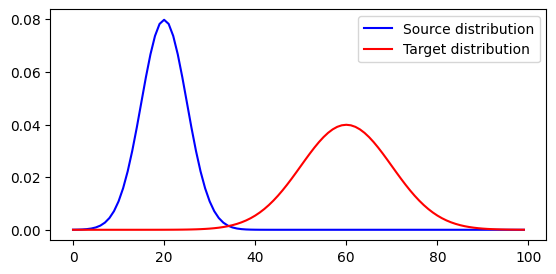

In [3]:
pl.figure(1, figsize=(6.4, 3))
pl.plot(x, a, "b", label="Source distribution")
pl.plot(x, b, "r", label="Target distribution")
pl.legend()

(<Axes: >, <Axes: >, <Axes: >)

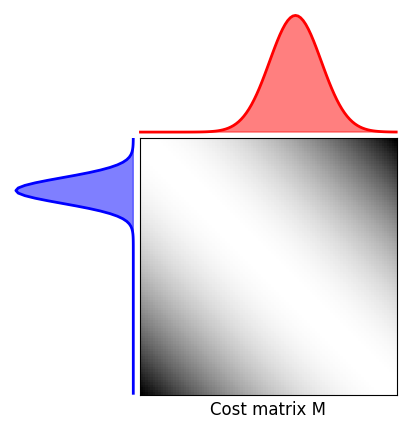

In [4]:
pl.figure(2, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, M, "Cost matrix M")

## Solve Exact OT

(<Axes: >, <Axes: >, <Axes: >)

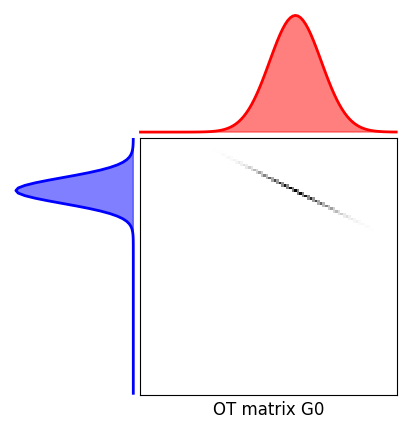

In [6]:
# G0 = ot.emd_1d(x, x, a, b)

# Equivalent to
G0 = ot.emd(a, b, M)

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, G0, "OT matrix G0")

## Solve Sinkhorn

It.  |Err         
-------------------
    0|2.784425e-01|
   10|2.797045e-02|
   20|1.496857e-03|
   30|7.983119e-05|
   40|4.257432e-06|
   50|2.270503e-07|
   60|1.210867e-08|


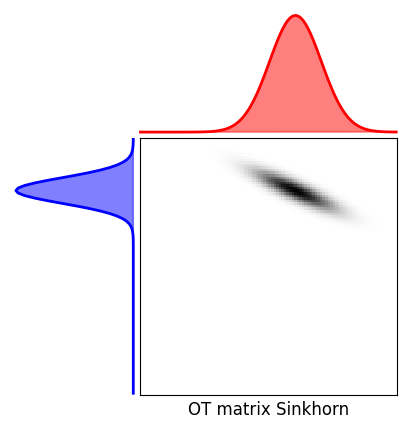

In [7]:
lambd = 3e-3
Gs = ot.sinkhorn(a, b, M, lambd, verbose=True)

pl.figure(4, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gs, "OT matrix Sinkhorn")
pl.show()

## Solve Smooth OT

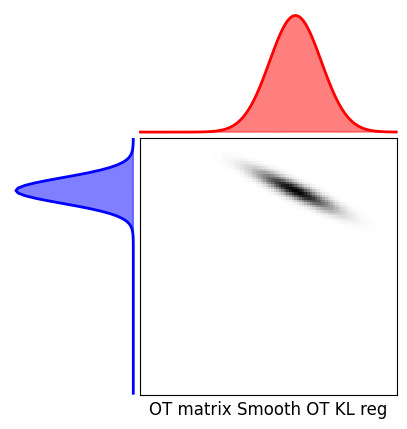

In [8]:
lambd = 2e-3
Gsm = ot.smooth.smooth_ot_dual(a, b, M, lambd, reg_type="kl")

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsm, "OT matrix Smooth OT KL reg")
pl.show()

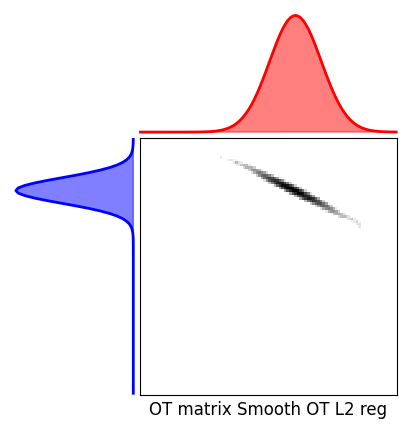

In [10]:
lambd = 1e-1
Gsm = ot.smooth.smooth_ot_dual(a, b, M, lambd, reg_type="l2")

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsm, "OT matrix Smooth OT L2 reg")
pl.show()

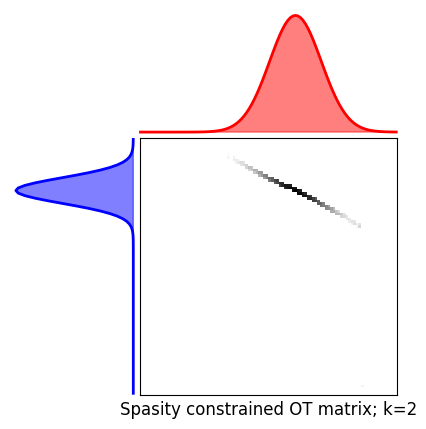

In [11]:
lambd = 1e-1

max_nz = 2
Gsc = ot.smooth.smooth_ot_dual(
  a, b, M, lambd, reg_type="sparsity_constrained", max_nz=max_nz
)
pl.figure(6, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gsc, "Spasity constrained OT matrix; k=2")
pl.show()